# 03 — The Same Task, Two Worlds

The second major finding: **deployment context determines automation, not the task itself.**

The same O*NET task — performed on the API (programmatic) vs. Claude.ai (interactive) —
shows radically different automation rates. Some tasks go from 0% automated on Claude.ai
to 100% automated on API. This means the question isn't "which tasks will AI automate?"
but "how will organizations choose to deploy AI for these tasks?"

In [1]:
import sys
sys.path.insert(0, "..")

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from src.data import build_task_feature_matrix
from src.features import compute_platform_gap
from src.model import train_task_autonomy_models

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 150
C = {'auto': '#E63946', 'aug': '#457B9D', 'accent': '#F4A261', 'teal': '#2A9D8F'}

In [2]:
gap = compute_platform_gap()
print(f'Tasks with data on both platforms: {len(gap):,}')
print(f'Mean automation gap (API - Claude.ai): {gap["automation_gap"].mean():+.1%}')
print(f'Tasks where API is more automated: {(gap["automation_gap"] > 0).sum()} ({(gap["automation_gap"] > 0).mean():.0%})')

Tasks with data on both platforms: 2,429
Mean automation gap (API - Claude.ai): +25.4%
Tasks where API is more automated: 1902 (78%)


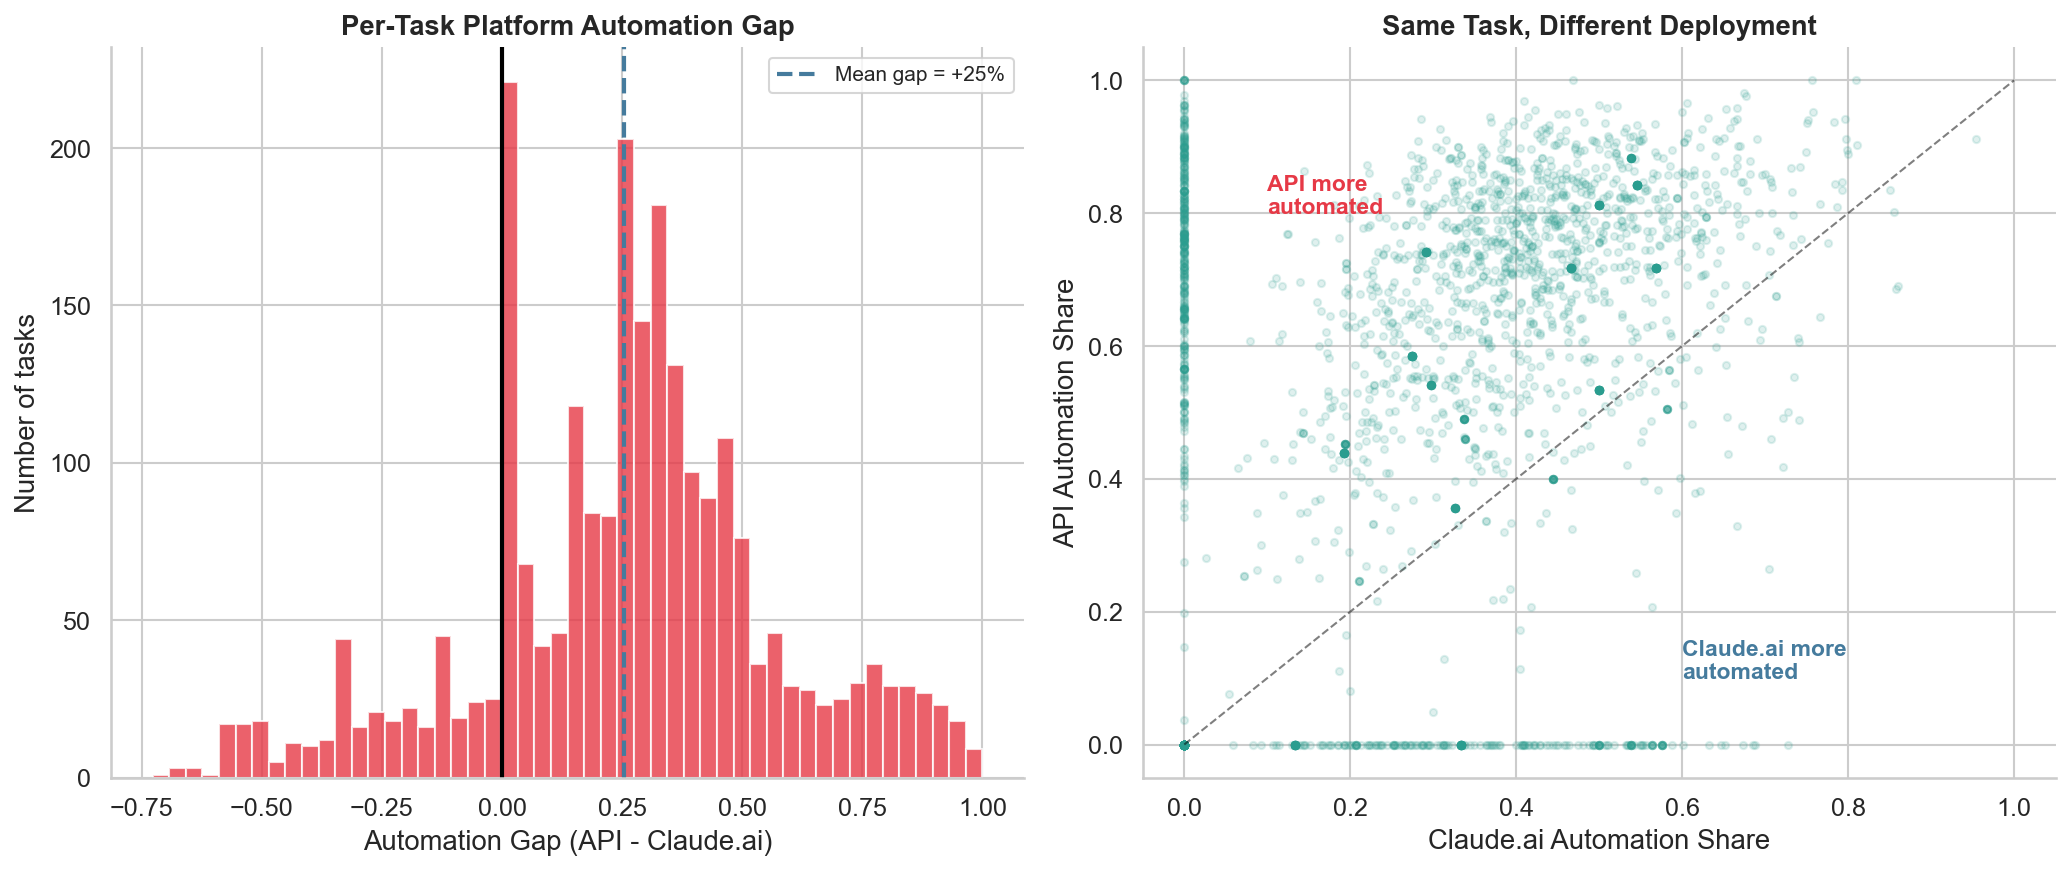

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: distribution of gaps
ax = axes[0]
ax.hist(gap['automation_gap'], bins=50, color=C['auto'], alpha=0.8, edgecolor='white')
ax.axvline(0, color='black', linewidth=2)
ax.axvline(gap['automation_gap'].mean(), color=C['aug'], linestyle='--', linewidth=2,
           label=f"Mean gap = {gap['automation_gap'].mean():+.0%}")
ax.set_xlabel('Automation Gap (API - Claude.ai)')
ax.set_ylabel('Number of tasks')
ax.set_title('Per-Task Platform Automation Gap', fontweight='bold')
ax.legend(fontsize=10)

# Right: scatter
ax = axes[1]
ax.scatter(gap['automation_share'], gap['automation_share_api'],
           alpha=0.15, s=12, color=C['teal'])
ax.plot([0, 1], [0, 1], '--', color='black', linewidth=1, alpha=0.5)
ax.set_xlabel('Claude.ai Automation Share')
ax.set_ylabel('API Automation Share')
ax.set_title('Same Task, Different Deployment', fontweight='bold')
ax.annotate('API more\nautomated', xy=(0.1, 0.8), fontsize=11, color=C['auto'], fontweight='bold')
ax.annotate('Claude.ai more\nautomated', xy=(0.6, 0.1), fontsize=11, color=C['aug'], fontweight='bold')

sns.despine()
plt.tight_layout()
plt.savefig('../figures/08_platform_divergence.png', bbox_inches='tight')
plt.show()

## Extreme examples: 0% to 100% automation by changing platform

In [4]:
extreme = gap[(gap['automation_share'] < 0.05) & (gap['automation_share_api'] > 0.9)]
print(f'{len(extreme)} tasks go from ~0% automated on Claude.ai to ~100% on API:\n')
for _, r in extreme.head(10).iterrows():
    print(f"  {r['task_name'][:75]}")
    print(f"    Claude.ai: {r['automation_share']:.0%}  ->  API: {r['automation_share_api']:.0%}")
    print()

print('These are not different tasks. They are the SAME task, deployed differently.')
print('The automation question is a deployment question, not a technology question.')

44 tasks go from ~0% automated on Claude.ai to ~100% on API:

  analyze statistical data and reports to identify and determine causes of pe
    Claude.ai: 0%  ->  API: 92%

  analyze statistical data and reports to identify and determine causes of pe
    Claude.ai: 0%  ->  API: 92%

  conduct needs assessments to identify document management requirements of d
    Claude.ai: 0%  ->  API: 100%

  consult sources such as rate books, manuals, or insurance company represent
    Claude.ai: 0%  ->  API: 93%

  coordinate sales or other promotional strategies with merchandising, operat
    Claude.ai: 0%  ->  API: 96%

  develop prospects from current commercial customers, referral leads, or sal
    Claude.ai: 0%  ->  API: 94%

  document account activities, generate reports, and keep records of business
    Claude.ai: 0%  ->  API: 93%

  evaluate and approve selection of vendors by studying past performance or n
    Claude.ai: 0%  ->  API: 94%

  evaluate vendor products and performance, negot

## Task-level predictive model

With 3,259 tasks and continuous outcome variables, we can predict AI autonomy
from task characteristics — something that fails completely at the occupation level.

In [5]:
tasks = build_task_feature_matrix()
tasks_unique = tasks.drop_duplicates(subset='task_name').reset_index(drop=True)

task_results = train_task_autonomy_models(tasks_unique)
best = max(task_results, key=lambda r: r.metrics['r2_cv_mean'])

print('Task-Level AI Autonomy Prediction')
print('=' * 50)
for r in task_results:
    print(f"\n{r.name}:")
    print(f"  R2 (train):  {r.metrics['r2_train']:.3f}")
    print(f"  R2 (5-fold): {r.metrics['r2_cv_mean']:.3f} +/- {r.metrics['r2_cv_std']:.3f}")

print(f"\nFor comparison: occupation-level velocity prediction achieves R2 ~ 0.")
print(f"Task-level analysis recovers signal that occupation aggregation destroys.")

Task-Level AI Autonomy Prediction

XGBoost:
  R2 (train):  0.752
  R2 (5-fold): 0.279 +/- 0.065

GradientBoosting:
  R2 (train):  0.657
  R2 (5-fold): 0.288 +/- 0.055

For comparison: occupation-level velocity prediction achieves R2 ~ 0.
Task-level analysis recovers signal that occupation aggregation destroys.


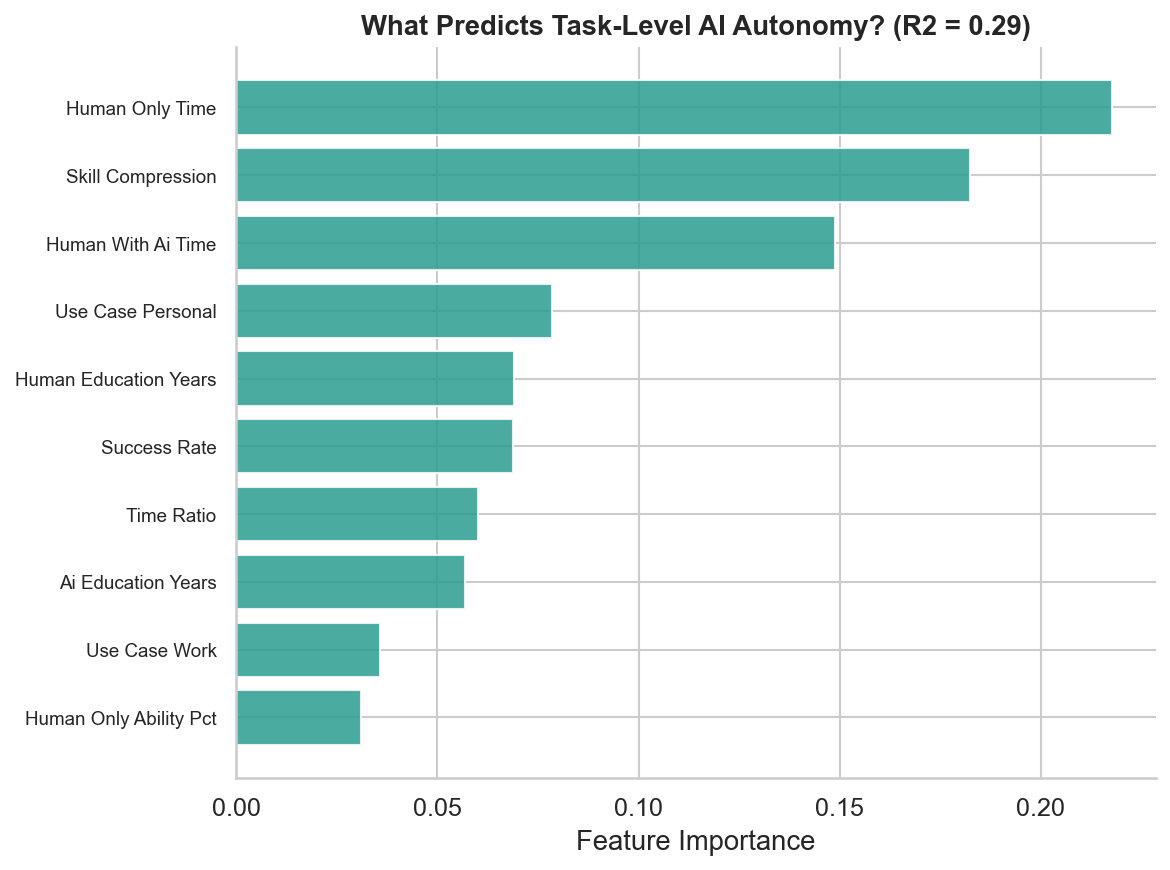

In [6]:
fig, ax = plt.subplots(figsize=(8, 6))
imp = best.feature_importance.head(10)
ax.barh(range(len(imp)), imp['importance'], color=C['teal'], alpha=0.85)
ax.set_yticks(range(len(imp)))
ax.set_yticklabels(imp['feature'].str.replace('_', ' ').str.title().values, fontsize=9)
ax.invert_yaxis()
ax.set_title(f'What Predicts Task-Level AI Autonomy? (R2 = {best.metrics["r2_cv_mean"]:.2f})',
             fontweight='bold')
ax.set_xlabel('Feature Importance')
sns.despine()
plt.tight_layout()
plt.savefig('../figures/09_task_model_importance.png', bbox_inches='tight')
plt.show()

---

**Key findings:**
1. **Same task, different automation rates** — deployment context (API vs Claude.ai) swings automation by +25pp on average, and up to 100pp for specific tasks
2. **Automation is a deployment decision**, not an intrinsic property of the task
3. **Task-level R^2 = 0.29** vs occupation-level R^2 ~ 0 — signal exists at the right granularity
4. **Time estimates and skill compression** are the strongest predictors of AI autonomy

**Next:** [04_jagged_frontier.ipynb](04_jagged_frontier.ipynb)